# CCMA Four-Run Comparison: Internal Benchmark and SHAP

This notebook compares the four CCMA runs documented in `docs/ccma_runs/checkpoint_journal.md`:

- `20260225_133435` (transfer, no methylation)
- `20260225_223235` (scratch, no methylation)
- `20260226_024535` (transfer, +methylation)
- `20260226_031500` (scratch, +methylation)

It focuses on two outputs:

1. Internal benchmark (`reports/vae/internal/*_entry_metrics.csv` and `*_feature_summary.csv`)
2. SHAP global rankings (`reports/vae/files/*_shap_omic_ranking_crisprcas9.csv` and `*_shap_feature_ranking_crisprcas9.csv`)


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
        "figure.titlesize": 18,
    }
)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif not (ROOT / "reports").exists() and (ROOT.parent / "reports").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import PhenPred

FILES_DIR = ROOT / "reports" / "vae" / "files"
INTERNAL_DIR = ROOT / "reports" / "vae" / "internal"
OUT_DIR = ROOT / "reports" / "vae" / "ccma_compare"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("FILES_DIR:", FILES_DIR)
print("INTERNAL_DIR:", INTERNAL_DIR)
print("OUT_DIR:", OUT_DIR)


ROOT: /mnt/hackathon-team2-8bf1s/scai/PhenPred
FILES_DIR: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files
INTERNAL_DIR: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/internal
OUT_DIR: /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/ccma_compare


In [19]:
RUNS = [
    {
        "timestamp": "20260225_133435",
        "mode": "transfer",
        "methylation": False,
    },
    {
        "timestamp": "20260225_223235",
        "mode": "scratch",
        "methylation": False,
    },
    {
        "timestamp": "20260226_024535",
        "mode": "transfer",
        "methylation": True,
    },
    {
        "timestamp": "20260226_031500",
        "mode": "scratch",
        "methylation": True,
    },
]

runs_df = pd.DataFrame(RUNS)
runs_df["display_label"] = runs_df.apply(
    lambda r: f"{r['mode']} | {'+ methylation' if r['methylation'] else 'no methylation'}",
    axis=1,
)
display(runs_df)


def parse_markdown_table(md_path):
    lines = md_path.read_text().splitlines()
    table_lines = [ln for ln in lines if ln.strip().startswith("|")]
    if len(table_lines) < 3:
        return pd.DataFrame()

    header = [c.strip() for c in table_lines[0].strip().strip("|").split("|")]
    rows = []
    for ln in table_lines[2:]:
        values = [c.strip() for c in ln.strip().strip("|").split("|")]
        if len(values) != len(header):
            continue
        rows.append(dict(zip(header, values)))

    return pd.DataFrame(rows)


journal_path = ROOT / "docs" / "ccma_runs" / "checkpoint_journal.md"
journal_df = parse_markdown_table(journal_path)

if not journal_df.empty and "Run Timestamp" in journal_df.columns:
    journal_filtered = journal_df[
        journal_df["Run Timestamp"].isin(runs_df["timestamp"])
    ].copy()
    display(journal_filtered)
else:
    print("Could not parse run table from checkpoint journal.")


,timestamp,mode,methylation,display_label
0,20260225_133435,transfer,False,transfer | no methylation
1,20260225_223235,scratch,False,scratch | no methylation
2,20260226_024535,transfer,True,transfer | + methylation
3,20260226_031500,scratch,True,scratch | + methylation


,Date Logged,Run Timestamp,Checkpoint Path,Mode,Config,What Was Done
1,2026-02-25,20260225_133435,`reports/vae/files/20260225_133435_model.pt`,CCMA transfer run,`reports/vae/files/hyperparameters_ccma_transf...,Trained on CCMA with transfer loading enabled;...
2,2026-02-25,20260225_223235,`reports/vae/files/<TIMESTAMP>_model.pt`,CCMA scratch run,`docs/ccma_runs/hyperparameters_ccma_scratch.j...,Planned baseline run with transfer loading dis...
3,2026-02-26,20260226_024535,`reports/vae/files/20260226_024535_model.pt`,CCMA transfer run (methylation),`reports/vae/files/hyperparameters_ccma_transf...,CCMA transfer run including methylation data; ...
4,2026-02-26,20260226_031500,`reports/vae/files/20260226_031500_model.pt`,CCMA scratch run (methylation),`docs/ccma_runs/hyperparameters_ccma_scratch.j...,CCMA baseline run including methylation data; ...


In [20]:
required_paths = []

for ts in runs_df["timestamp"]:
    required_paths.extend(
        [
            INTERNAL_DIR / f"{ts}_all_entry_metrics.csv",
            INTERNAL_DIR / f"{ts}_cv_entry_metrics.csv",
            INTERNAL_DIR / f"{ts}_all_feature_summary.csv",
            INTERNAL_DIR / f"{ts}_cv_feature_summary.csv",
            FILES_DIR / f"{ts}_shap_omic_ranking_crisprcas9.csv",
            FILES_DIR / f"{ts}_shap_feature_ranking_crisprcas9.csv",
        ]
    )

check_rows = []
for p in required_paths:
    check_rows.append(
        {
            "path": str(p.relative_to(ROOT)),
            "exists": p.exists(),
            "size_mb": (p.stat().st_size / (1024 ** 2)) if p.exists() else np.nan,
        }
    )

checks_df = pd.DataFrame(check_rows)
display(checks_df)

missing = checks_df.loc[~checks_df["exists"], "path"].tolist()
if missing:
    raise FileNotFoundError("Missing required comparison files:\n" + "\n".join(missing))


,path,exists,size_mb
0,reports/vae/internal/20260225_133435_all_entry...,True,0.000240
1,reports/vae/internal/20260225_133435_cv_entry_...,True,0.000237
2,reports/vae/internal/20260225_133435_all_featu...,True,0.000214
3,reports/vae/internal/20260225_133435_cv_featur...,True,0.000216
4,reports/vae/files/20260225_133435_shap_omic_ra...,True,0.000093
5,reports/vae/files/20260225_133435_shap_feature...,True,0.351890
6,reports/vae/internal/20260225_223235_all_entry...,True,0.000240
7,reports/vae/internal/20260225_223235_cv_entry_...,True,0.000240
8,reports/vae/internal/20260225_223235_all_featu...,True,0.000216
9,reports/vae/internal/20260225_223235_cv_featur...,True,0.000216


## Internal Benchmark Comparison


In [21]:
def load_internal_table(ts, source, table_name):
    path = INTERNAL_DIR / f"{ts}_{source}_{table_name}.csv"
    df = pd.read_csv(path)
    df["timestamp"] = ts
    df["source"] = source
    return df


entry_parts = []
feature_parts = []
for ts in runs_df["timestamp"]:
    for source in ["all", "cv"]:
        entry_parts.append(load_internal_table(ts, source, "entry_metrics"))
        feature_parts.append(load_internal_table(ts, source, "feature_summary"))

internal_entry_df = pd.concat(entry_parts, ignore_index=True)
internal_feature_df = pd.concat(feature_parts, ignore_index=True)

meta_cols = ["timestamp", "mode", "methylation", "display_label"]
internal_entry_df = internal_entry_df.merge(
    runs_df[meta_cols], on="timestamp", how="left"
)
internal_feature_df = internal_feature_df.merge(
    runs_df[meta_cols], on="timestamp", how="left"
)

print("entry rows:", len(internal_entry_df))
print("feature rows:", len(internal_feature_df))
display(internal_entry_df.head())
display(internal_feature_df.head())


entry rows: 20
feature rows: 20


,source,n_obs,rmse,mae,pearson,spearman,view_name,timestamp,mode,methylation,display_label
0,all,2626220,0.124960,0.083434,0.954451,0.886745,crisprcas9,20260225_133435,transfer,False,transfer | no methylation
1,all,2225727,0.609685,0.397167,0.968770,0.965556,transcriptomics,20260225_133435,transfer,False,transfer | no methylation
2,cv,2626220,0.224077,0.144163,0.844848,0.685105,crisprcas9,20260225_133435,transfer,False,transfer | no methylation
3,cv,2225727,0.968281,0.662490,0.919001,0.913775,transcriptomics,20260225_133435,transfer,False,transfer | no methylation
4,all,2626220,0.123938,0.082292,0.955272,0.887251,crisprcas9,20260225_223235,scratch,False,scratch | no methylation


,source,view_name,n_features,pearson_median,pearson_q1,pearson_q3,timestamp,mode,methylation,display_label
0,all,crisprcas9,17876,0.846621,0.822573,0.869056,20260225_133435,transfer,False,transfer | no methylation
1,all,transcriptomics,15141,0.850543,0.809509,0.884716,20260225_133435,transfer,False,transfer | no methylation
2,cv,crisprcas9,17876,0.202549,0.081773,0.327623,20260225_133435,transfer,False,transfer | no methylation
3,cv,transcriptomics,15141,0.478046,0.342697,0.590051,20260225_133435,transfer,False,transfer | no methylation
4,all,crisprcas9,17876,0.849378,0.824703,0.872623,20260225_223235,scratch,False,scratch | no methylation


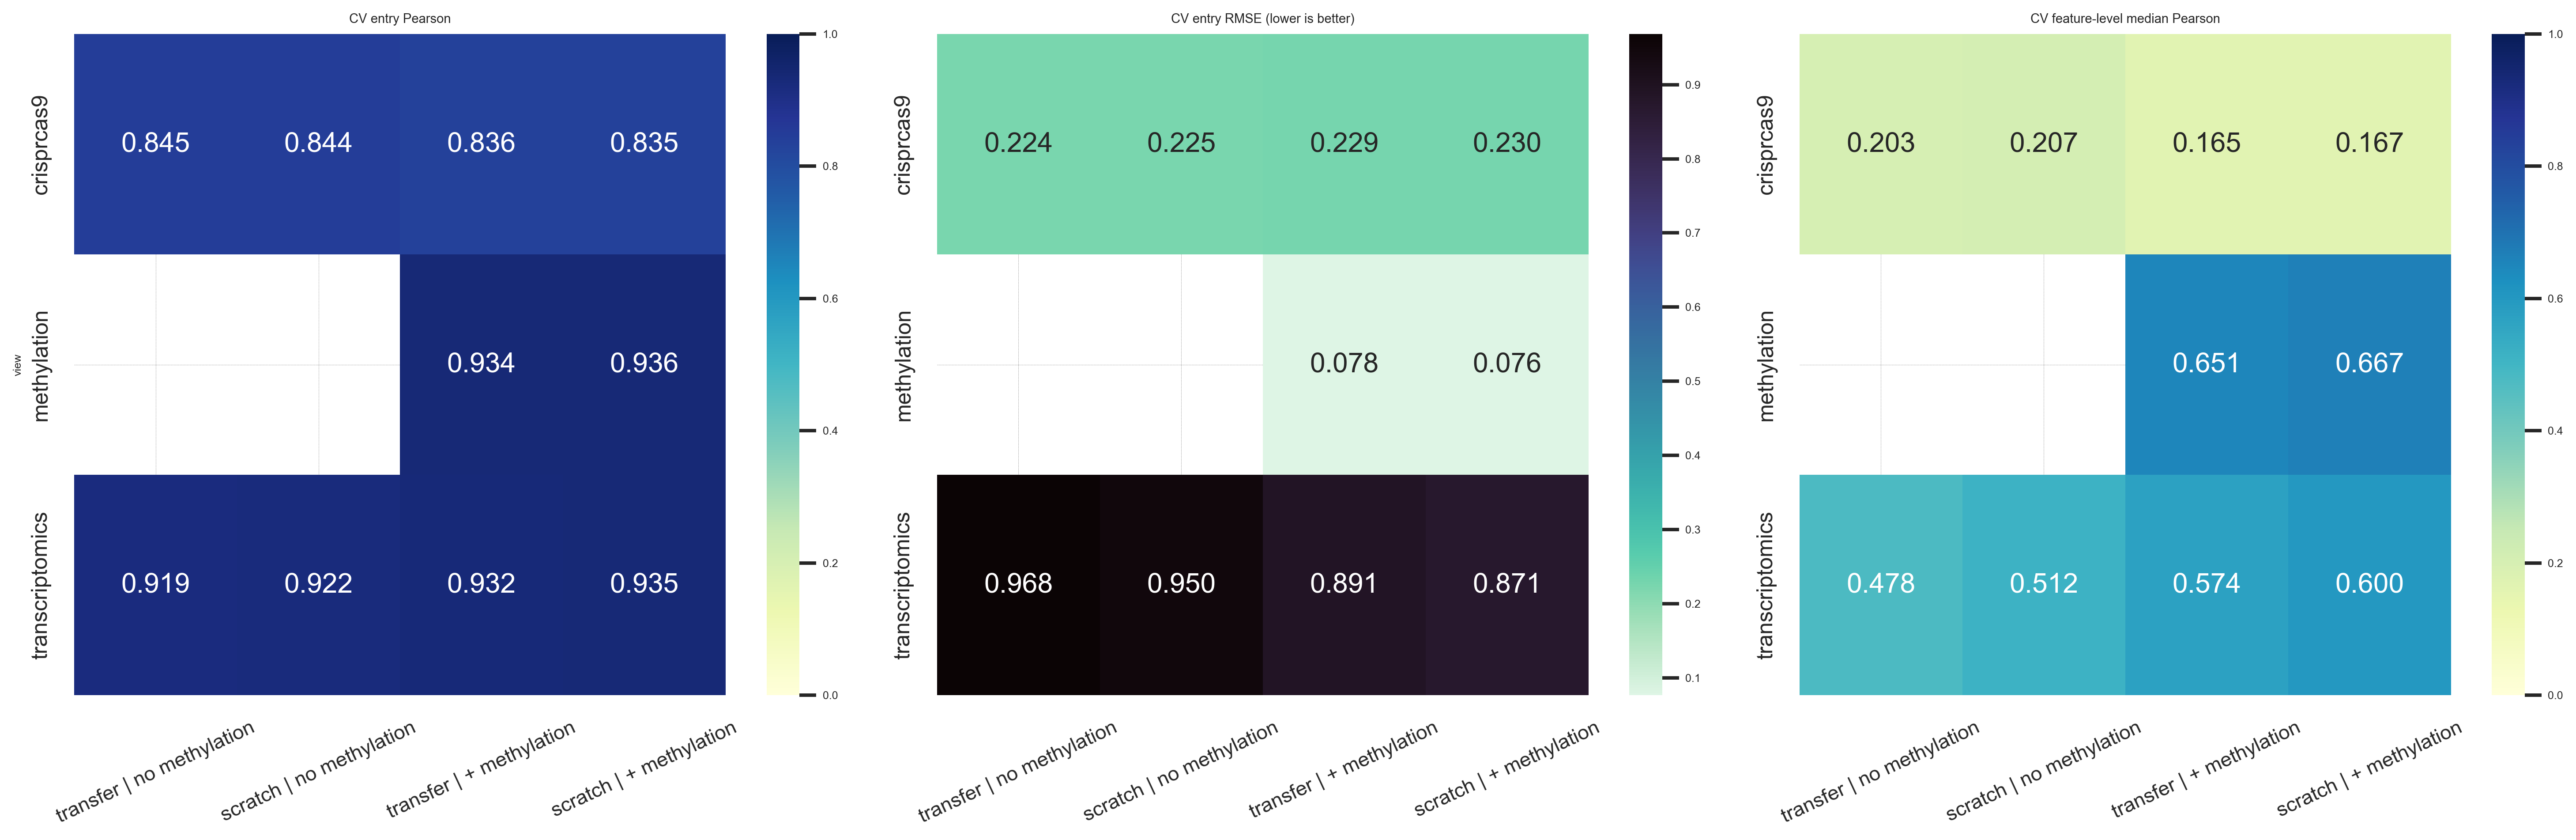

Best run per view by CV entry Pearson:


,view_name,display_label,pearson
0,crisprcas9,transfer | no methylation,0.844848
1,methylation,scratch | + methylation,0.936402
2,transcriptomics,scratch | + methylation,0.934699


Best run per view by CV entry RMSE:


,view_name,display_label,rmse
0,crisprcas9,transfer | no methylation,0.224077
1,methylation,scratch | + methylation,0.076386
2,transcriptomics,scratch | + methylation,0.871030


In [22]:
source_to_plot = "cv"
entry_plot_df = internal_entry_df.query("source == @source_to_plot").copy()
feature_plot_df = internal_feature_df.query("source == @source_to_plot").copy()

run_order = runs_df["display_label"].tolist()

pearson_pivot = (
    entry_plot_df.pivot(index="view_name", columns="display_label", values="pearson")
    .reindex(columns=run_order)
)
rmse_pivot = (
    entry_plot_df.pivot(index="view_name", columns="display_label", values="rmse")
    .reindex(columns=run_order)
)
feat_pivot = (
    feature_plot_df.pivot(
        index="view_name", columns="display_label", values="pearson_median"
    )
    .reindex(columns=run_order)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

sns.heatmap(
    pearson_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    ax=axes[0],
    annot_kws={"size": 15},
)
axes[0].set_title("CV entry Pearson")
axes[0].set_xlabel("")
axes[0].set_ylabel("view")

sns.heatmap(
    rmse_pivot,
    annot=True,
    fmt=".3f",
    cmap="mako_r",
    ax=axes[1],
    annot_kws={"size": 15},
)
axes[1].set_title("CV entry RMSE (lower is better)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.heatmap(
    feat_pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    ax=axes[2],
    annot_kws={"size": 15},
)
axes[2].set_title("CV feature-level median Pearson")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=25, labelsize=11)
    ax.tick_params(axis="y", labelsize=12)

fig.tight_layout()
fig.savefig(OUT_DIR / "internal_cv_comparison_heatmaps.png", dpi=220)
plt.show()

best_pearson = (
    entry_plot_df.sort_values("pearson", ascending=False)
    .groupby("view_name", as_index=False)
    .first()[["view_name", "display_label", "pearson"]]
)
best_rmse = (
    entry_plot_df.sort_values("rmse", ascending=True)
    .groupby("view_name", as_index=False)
    .first()[["view_name", "display_label", "rmse"]]
)

print("Best run per view by CV entry Pearson:")
display(best_pearson)
print("Best run per view by CV entry RMSE:")
display(best_rmse)


In [23]:
def transfer_minus_scratch(df, value_col):
    wide = df.pivot_table(
        index=["methylation", "view_name"],
        columns="mode",
        values=value_col,
        aggfunc="first",
    )
    if {"transfer", "scratch"}.issubset(wide.columns):
        wide["delta_transfer_minus_scratch"] = wide["transfer"] - wide["scratch"]
    return wide.reset_index().sort_values(["methylation", "view_name"])


pearson_delta = transfer_minus_scratch(entry_plot_df, "pearson")
rmse_delta = transfer_minus_scratch(entry_plot_df, "rmse")
feature_delta = transfer_minus_scratch(feature_plot_df, "pearson_median")

print("CV entry Pearson: transfer - scratch")
display(pearson_delta)

print("CV entry RMSE: transfer - scratch")
display(rmse_delta)

print("CV feature median Pearson: transfer - scratch")
display(feature_delta)


CV entry Pearson: transfer - scratch


mode,methylation,view_name,scratch,transfer,delta_transfer_minus_scratch
0,False,crisprcas9,0.844116,0.844848,0.000732
1,False,transcriptomics,0.922142,0.919001,-0.003141
2,True,crisprcas9,0.834574,0.835576,0.001002
3,True,methylation,0.936402,0.933774,-0.002628
4,True,transcriptomics,0.934699,0.931549,-0.003150


CV entry RMSE: transfer - scratch


mode,methylation,view_name,scratch,transfer,delta_transfer_minus_scratch
0,False,crisprcas9,0.224573,0.224077,-0.000497
1,False,transcriptomics,0.950258,0.968281,0.018022
2,True,crisprcas9,0.229540,0.228921,-0.000619
3,True,methylation,0.076386,0.077876,0.001489
4,True,transcriptomics,0.871030,0.891048,0.020018


CV feature median Pearson: transfer - scratch


mode,methylation,view_name,scratch,transfer,delta_transfer_minus_scratch
0,False,crisprcas9,0.207412,0.202549,-0.004863
1,False,transcriptomics,0.512093,0.478046,-0.034048
2,True,crisprcas9,0.166602,0.165475,-0.001128
3,True,methylation,0.666712,0.650730,-0.015981
4,True,transcriptomics,0.599701,0.573837,-0.025865


## SHAP Comparison


In [24]:
def load_shap_tables(ts):
    feat = pd.read_csv(FILES_DIR / f"{ts}_shap_feature_ranking_crisprcas9.csv")
    omic = pd.read_csv(FILES_DIR / f"{ts}_shap_omic_ranking_crisprcas9.csv")

    for df in (feat, omic):
        df["omic_layer"] = df["omic_layer"].replace(
            {"conditionals": "mutation_conditionals"}
        )
        df["timestamp"] = ts

    feat["feature_short"] = feat["feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    return feat, omic


shap_feature_parts = []
shap_omic_parts = []
for ts in runs_df["timestamp"]:
    feat_df, omic_df = load_shap_tables(ts)
    shap_feature_parts.append(feat_df)
    shap_omic_parts.append(omic_df)

shap_feature_df = pd.concat(shap_feature_parts, ignore_index=True)
shap_omic_df = pd.concat(shap_omic_parts, ignore_index=True)

shap_feature_df = shap_feature_df.merge(runs_df[meta_cols], on="timestamp", how="left")
shap_omic_df = shap_omic_df.merge(runs_df[meta_cols], on="timestamp", how="left")
shap_omic_df["importance_fraction"] = (
    shap_omic_df["importance"]
    / shap_omic_df.groupby("display_label")["importance"].transform("sum")
)

display(
    shap_omic_df.sort_values(["display_label", "importance"], ascending=[True, False])
)
display(
    shap_feature_df.sort_values(["display_label", "importance"], ascending=[True, False]).head(20)
)


,omic_layer,importance,timestamp,mode,methylation,display_label,importance_fraction
7,transcriptomics,0.000293,20260226_031500,scratch,True,scratch | + methylation,0.519053
8,methylation,0.000254,20260226_031500,scratch,True,scratch | + methylation,0.449959
9,mutation_conditionals,0.000018,20260226_031500,scratch,True,scratch | + methylation,0.030988
2,transcriptomics,0.000225,20260225_223235,scratch,False,scratch | no methylation,0.902775
3,mutation_conditionals,0.000024,20260225_223235,scratch,False,scratch | no methylation,0.097225
4,transcriptomics,0.000341,20260226_024535,transfer,True,transfer | + methylation,0.497703
5,methylation,0.000332,20260226_024535,transfer,True,transfer | + methylation,0.484458
6,mutation_conditionals,0.000012,20260226_024535,transfer,True,transfer | + methylation,0.017839
0,transcriptomics,0.000224,20260225_133435,transfer,False,transfer | no methylation,0.910666
1,mutation_conditionals,0.000022,20260225_133435,transfer,False,transfer | no methylation,0.089334


,feature,importance,omic_layer,timestamp,feature_short,mode,methylation,display_label
24148,conditionals_mut_TP53,0.001612,mutation_conditionals,20260226_031500,mut_TP53,scratch,True,scratch | + methylation
24149,transcriptomics_RADX,0.001317,transcriptomics,20260226_031500,RADX,scratch,True,scratch | + methylation
24150,methylation_CMTM7,0.001292,methylation,20260226_031500,CMTM7,scratch,True,scratch | + methylation
24151,methylation_PRDX1,0.001225,methylation,20260226_031500,PRDX1,scratch,True,scratch | + methylation
24152,transcriptomics_COL25A1,0.001203,transcriptomics,20260226_031500,COL25A1,scratch,True,scratch | + methylation
24153,transcriptomics_ARHGEF28,0.001183,transcriptomics,20260226_031500,ARHGEF28,scratch,True,scratch | + methylation
24154,methylation_COL2A1,0.001182,methylation,20260226_031500,COL2A1,scratch,True,scratch | + methylation
24155,transcriptomics_TUBB3,0.001175,transcriptomics,20260226_031500,TUBB3,scratch,True,scratch | + methylation
24156,transcriptomics_SHANK2,0.001152,transcriptomics,20260226_031500,SHANK2,scratch,True,scratch | + methylation
24157,transcriptomics_CCDC159,0.001119,transcriptomics,20260226_031500,CCDC159,scratch,True,scratch | + methylation


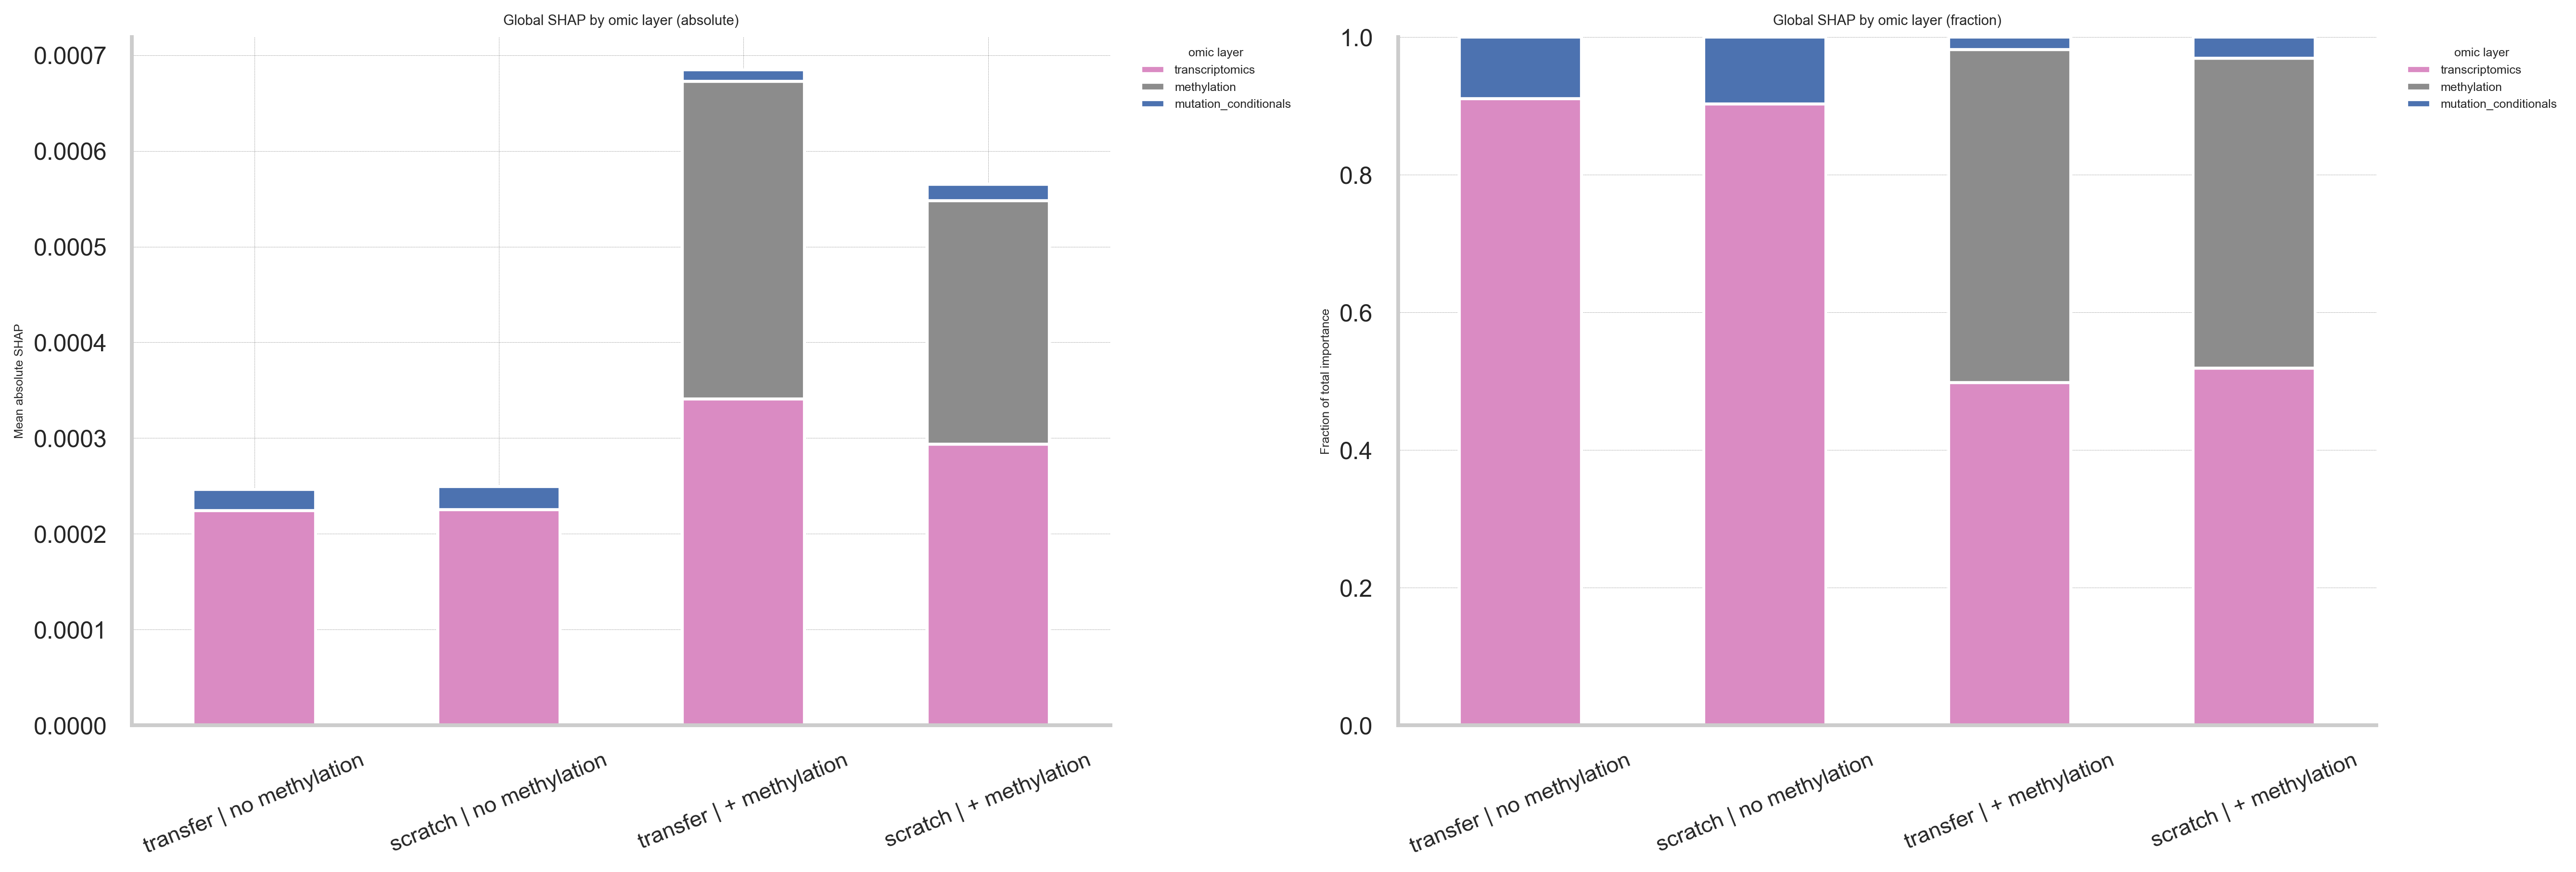

In [25]:
palette = dict(getattr(PhenPred, "OMIC_PALETTE", {}))
palette.setdefault("transcriptomics", "#4c72b0")
palette.setdefault("methylation", "#dd8452")
palette["mutation_conditionals"] = palette.get("conditionals", "#8c8c8c")

run_order = runs_df["display_label"].tolist()
layer_order = [
    layer
    for layer in ["transcriptomics", "methylation", "mutation_conditionals"]
    if layer in set(shap_omic_df["omic_layer"])
]
for layer in sorted(set(shap_omic_df["omic_layer"]) - set(layer_order)):
    layer_order.append(layer)

abs_pivot = (
    shap_omic_df.pivot(index="display_label", columns="omic_layer", values="importance")
    .reindex(index=run_order)
    .fillna(0.0)
)
frac_pivot = (
    shap_omic_df.pivot(
        index="display_label", columns="omic_layer", values="importance_fraction"
    )
    .reindex(index=run_order)
    .fillna(0.0)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6.2))

abs_pivot[layer_order].plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[palette.get(c, "#999999") for c in layer_order],
)
axes[0].set_title("Global SHAP by omic layer (absolute)")
axes[0].set_ylabel("Mean absolute SHAP")
axes[0].set_xlabel("")
axes[0].legend(title="omic layer", bbox_to_anchor=(1.02, 1), loc="upper left")

frac_pivot[layer_order].plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[palette.get(c, "#999999") for c in layer_order],
)
axes[1].set_title("Global SHAP by omic layer (fraction)")
axes[1].set_ylabel("Fraction of total importance")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1.0)
axes[1].legend(title="omic layer", bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=22, labelsize=11)
    ax.tick_params(axis="y", labelsize=12)

fig.tight_layout()
fig.savefig(OUT_DIR / "shap_omic_comparison.png", dpi=220)
plt.show()


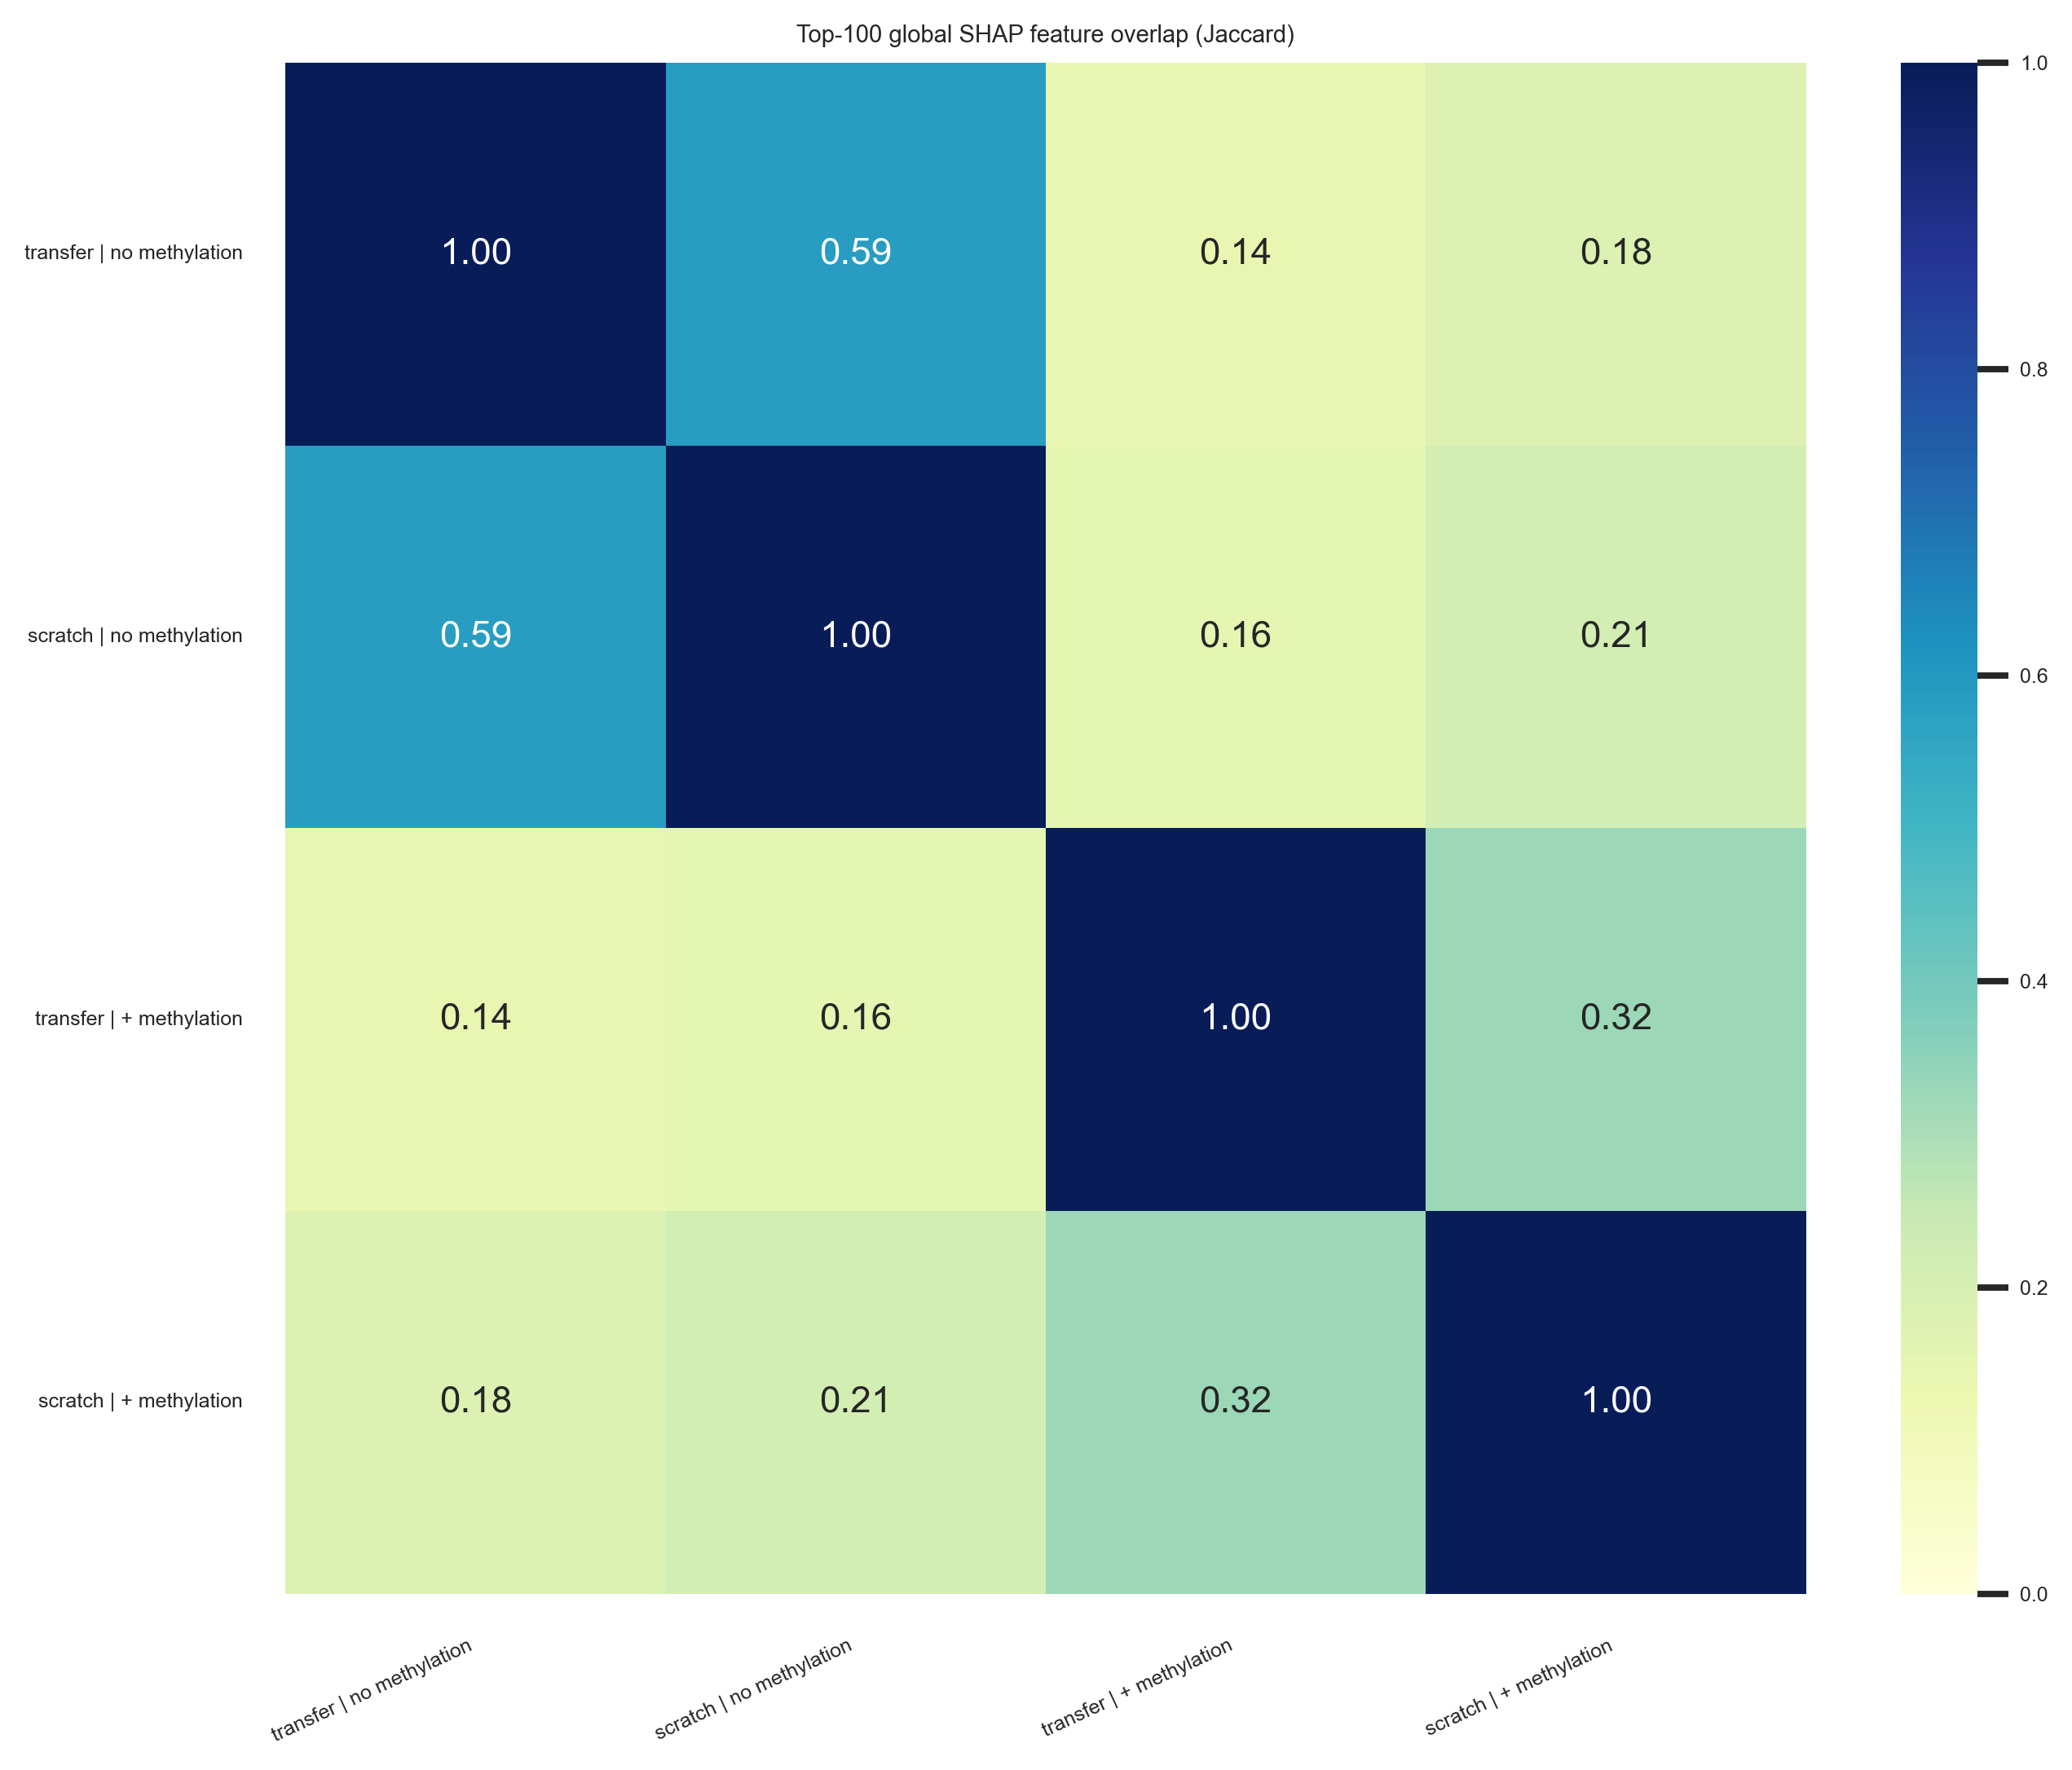

Shared features across all runs (top 100 each): 20


,shared_feature
0,conditionals_mut_TP53
1,transcriptomics_ARC
2,transcriptomics_CCDC159
3,transcriptomics_COL27A1
4,transcriptomics_EDN3
5,transcriptomics_EIF1AY
6,transcriptomics_FABP5
7,transcriptomics_FAHD2B
8,transcriptomics_FAIM
9,transcriptomics_KDM5D


Run-unique features among top-100 per run (first 20 each)


,run,feature,importance,omic_layer
0,transfer | no methylation,transcriptomics_FGF1,0.000749,transcriptomics
1,transfer | no methylation,transcriptomics_GIPR,0.000749,transcriptomics
2,transfer | no methylation,transcriptomics_OTX1,0.000721,transcriptomics
3,transfer | no methylation,transcriptomics_COL16A1,0.000716,transcriptomics
4,transfer | no methylation,transcriptomics_B3GNT9,0.000691,transcriptomics
...,...,...,...,...
73,scratch | + methylation,transcriptomics_CABLES1,0.000949,transcriptomics
74,scratch | + methylation,methylation_POU2F1,0.000948,methylation
75,scratch | + methylation,transcriptomics_ZNF793,0.000928,transcriptomics
76,scratch | + methylation,methylation_C18orf54,0.000927,methylation


In [26]:
TOP_K = 100
run_order = runs_df["display_label"].tolist()

top_feature_sets = {}
for label in run_order:
    top_df = (
        shap_feature_df[shap_feature_df["display_label"] == label]
        .sort_values("importance", ascending=False)
        .head(TOP_K)
    )
    top_feature_sets[label] = set(top_df["feature"])

jaccard = pd.DataFrame(index=run_order, columns=run_order, dtype=float)
for a in run_order:
    for b in run_order:
        inter = len(top_feature_sets[a].intersection(top_feature_sets[b]))
        union = len(top_feature_sets[a].union(top_feature_sets[b]))
        jaccard.loc[a, b] = inter / union if union else np.nan

plt.figure(figsize=(9.2, 7.4))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0.0, vmax=1.0, annot_kws={"size": 11})
plt.title(f"Top-{TOP_K} global SHAP feature overlap (Jaccard)")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_top_feature_jaccard_top100.png", dpi=220)
plt.show()

shared_all = sorted(set.intersection(*top_feature_sets.values())) if top_feature_sets else []
print(f"Shared features across all runs (top {TOP_K} each): {len(shared_all)}")
display(pd.DataFrame({"shared_feature": shared_all[:50]}))

unique_rows = []
for label in run_order:
    own_top = (
        shap_feature_df[shap_feature_df["display_label"] == label]
        .sort_values("importance", ascending=False)
        .head(TOP_K)
    )
    others_union = set().union(
        *[top_feature_sets[lbl] for lbl in run_order if lbl != label]
    )
    uniq_df = own_top[~own_top["feature"].isin(others_union)].head(20)
    for _, row in uniq_df.iterrows():
        unique_rows.append(
            {
                "run": label,
                "feature": row["feature"],
                "importance": row["importance"],
                "omic_layer": row["omic_layer"],
            }
        )

unique_top_df = pd.DataFrame(unique_rows)
print("Run-unique features among top-100 per run (first 20 each)")
display(unique_top_df)


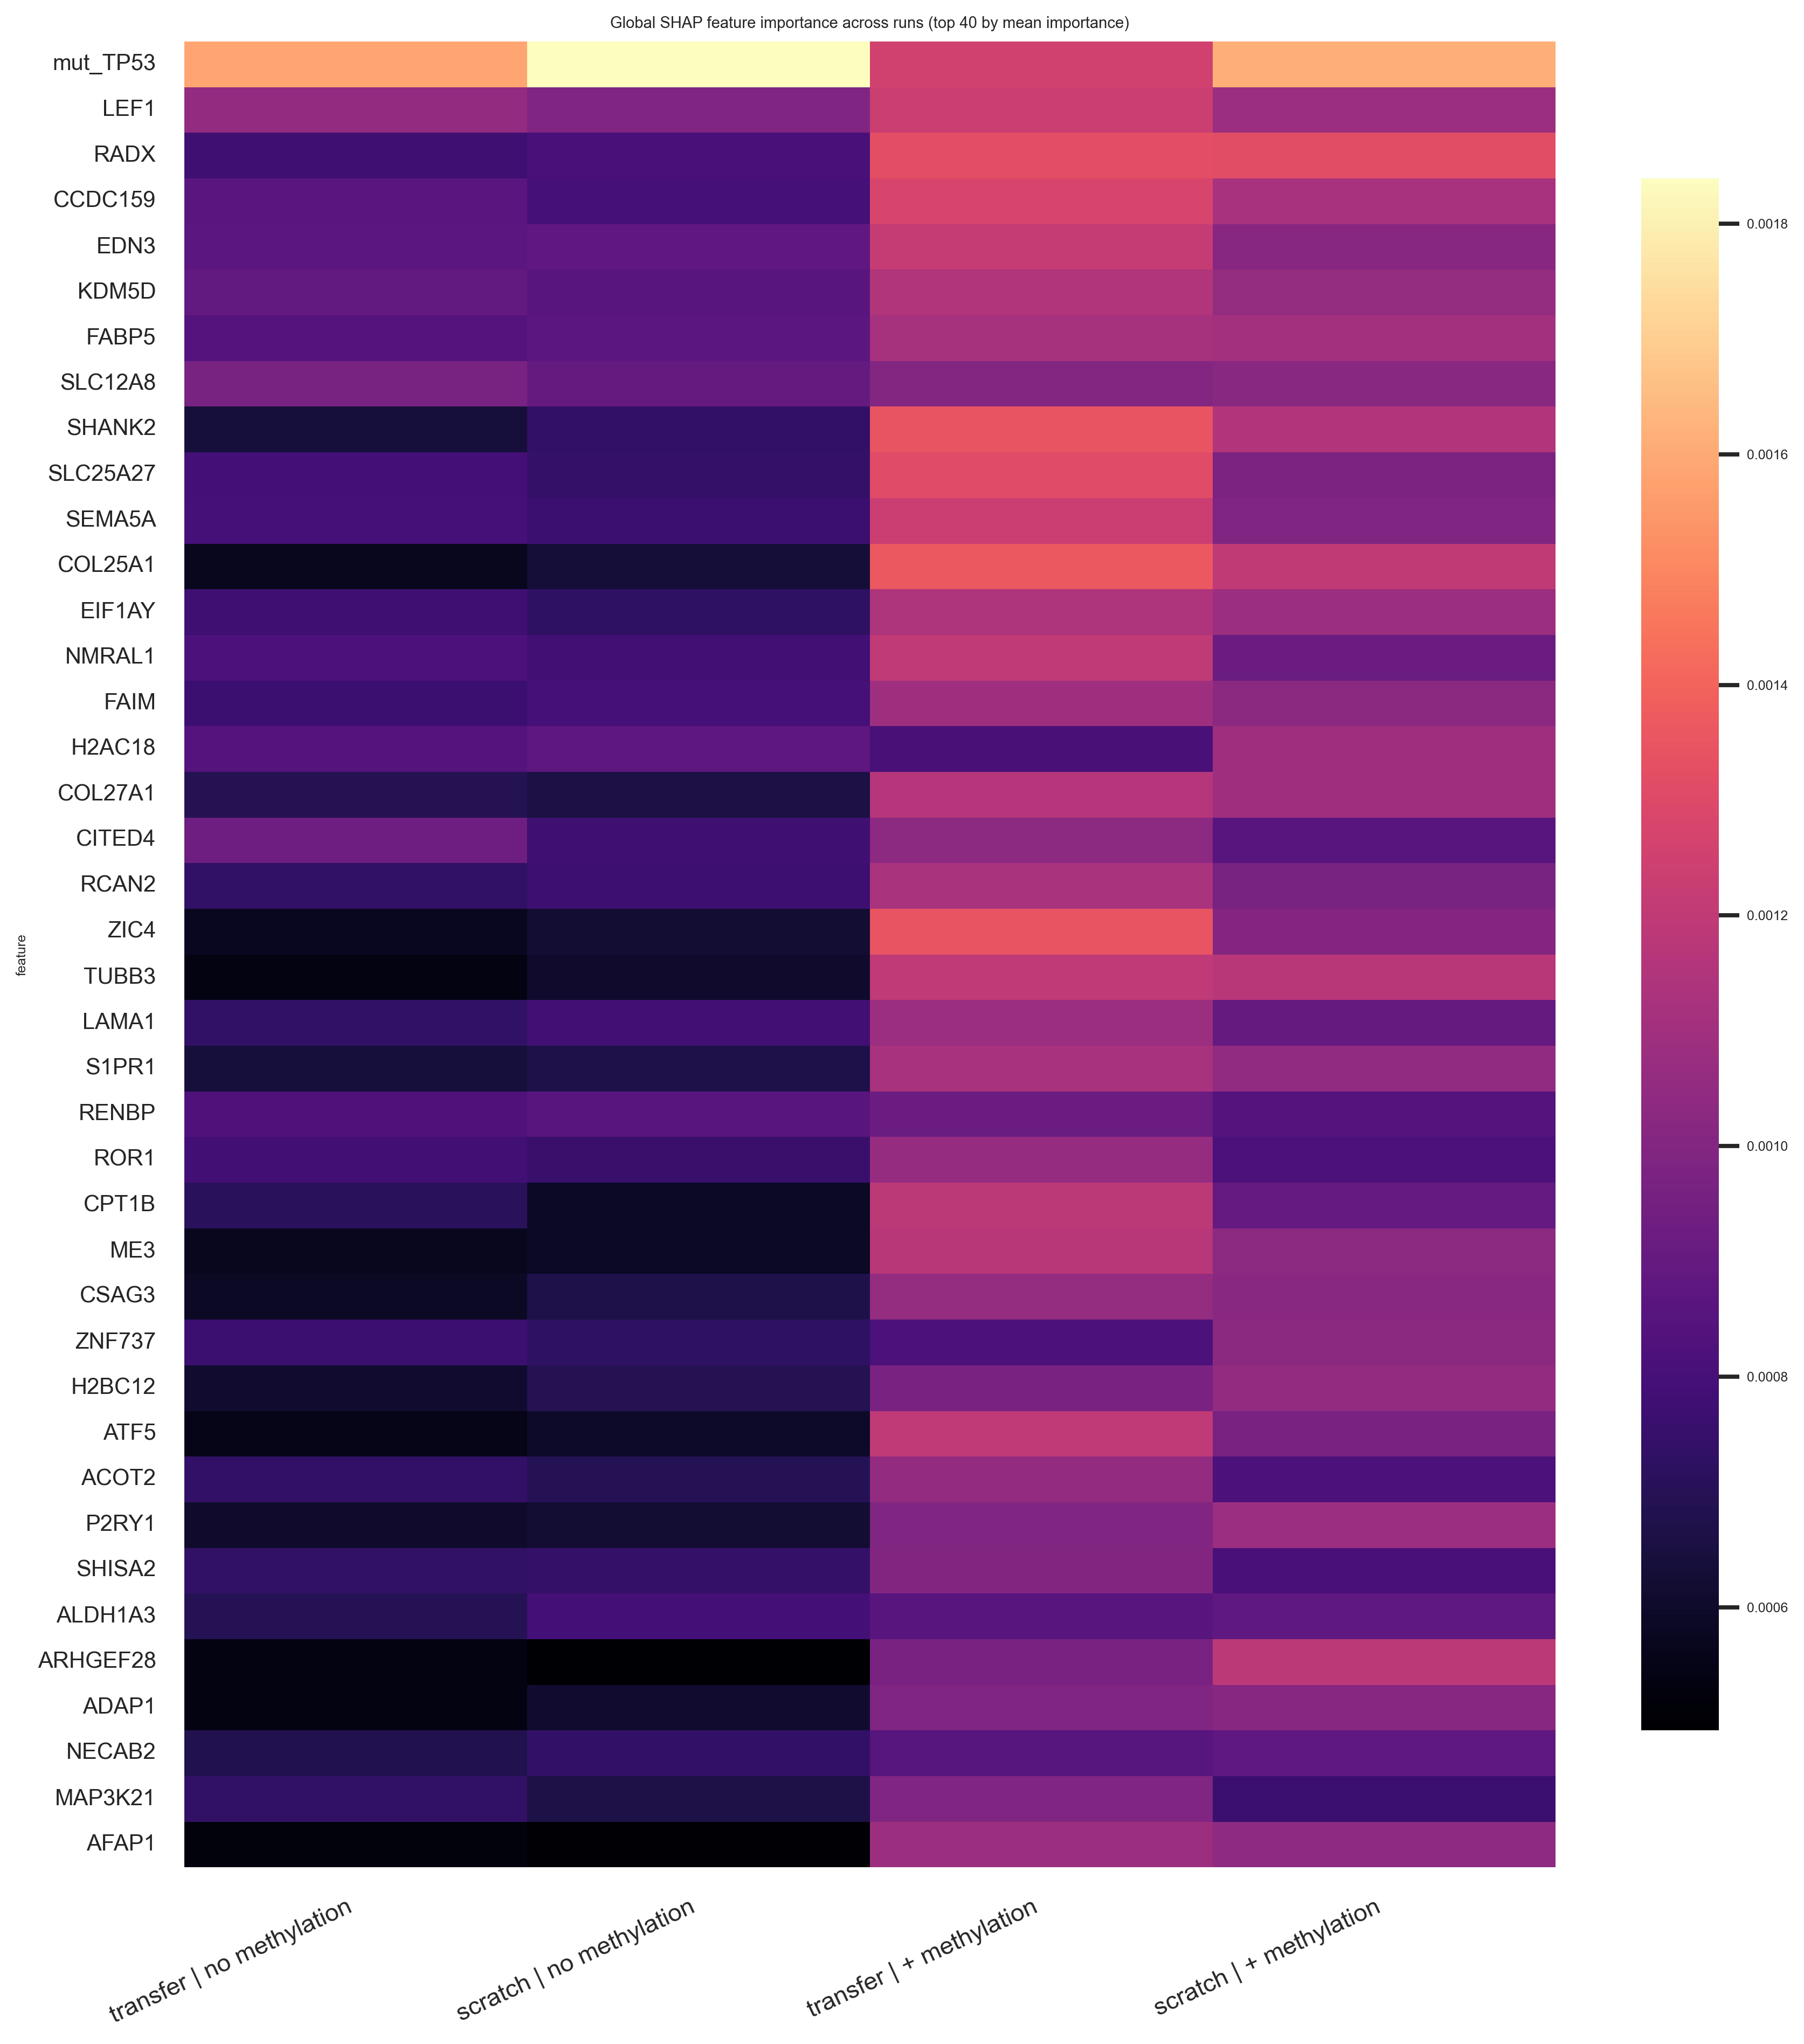

In [27]:
TOP_N_PER_RUN = 40
TOP_N_TO_PLOT = 40

run_order = runs_df["display_label"].tolist()
union_features = set()
for label in run_order:
    feats = (
        shap_feature_df[shap_feature_df["display_label"] == label]
        .sort_values("importance", ascending=False)
        .head(TOP_N_PER_RUN)["feature"]
        .tolist()
    )
    union_features.update(feats)

union_features = sorted(union_features)

feature_matrix = (
    shap_feature_df[shap_feature_df["feature"].isin(union_features)]
    .pivot(index="feature", columns="display_label", values="importance")
    .reindex(columns=run_order)
    .fillna(0.0)
)

top_features = (
    feature_matrix.mean(axis=1)
    .sort_values(ascending=False)
    .head(TOP_N_TO_PLOT)
    .index
)
plot_matrix = feature_matrix.loc[top_features]

yticklabels = [f.split("_", 1)[1] if "_" in f else f for f in plot_matrix.index]

plt.figure(figsize=(12, max(10, 0.32 * len(plot_matrix))))
sns.heatmap(
    plot_matrix,
    cmap="magma",
    yticklabels=yticklabels,
    cbar_kws={"shrink": 0.85},
)
plt.title(
    f"Global SHAP feature importance across runs (top {TOP_N_TO_PLOT} by mean importance)"
)
plt.xlabel("")
plt.ylabel("feature")
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_top_feature_heatmap.png", dpi=220)
plt.show()


### Global Top Features Per Run

This section plots the top global SHAP features for each run separately.


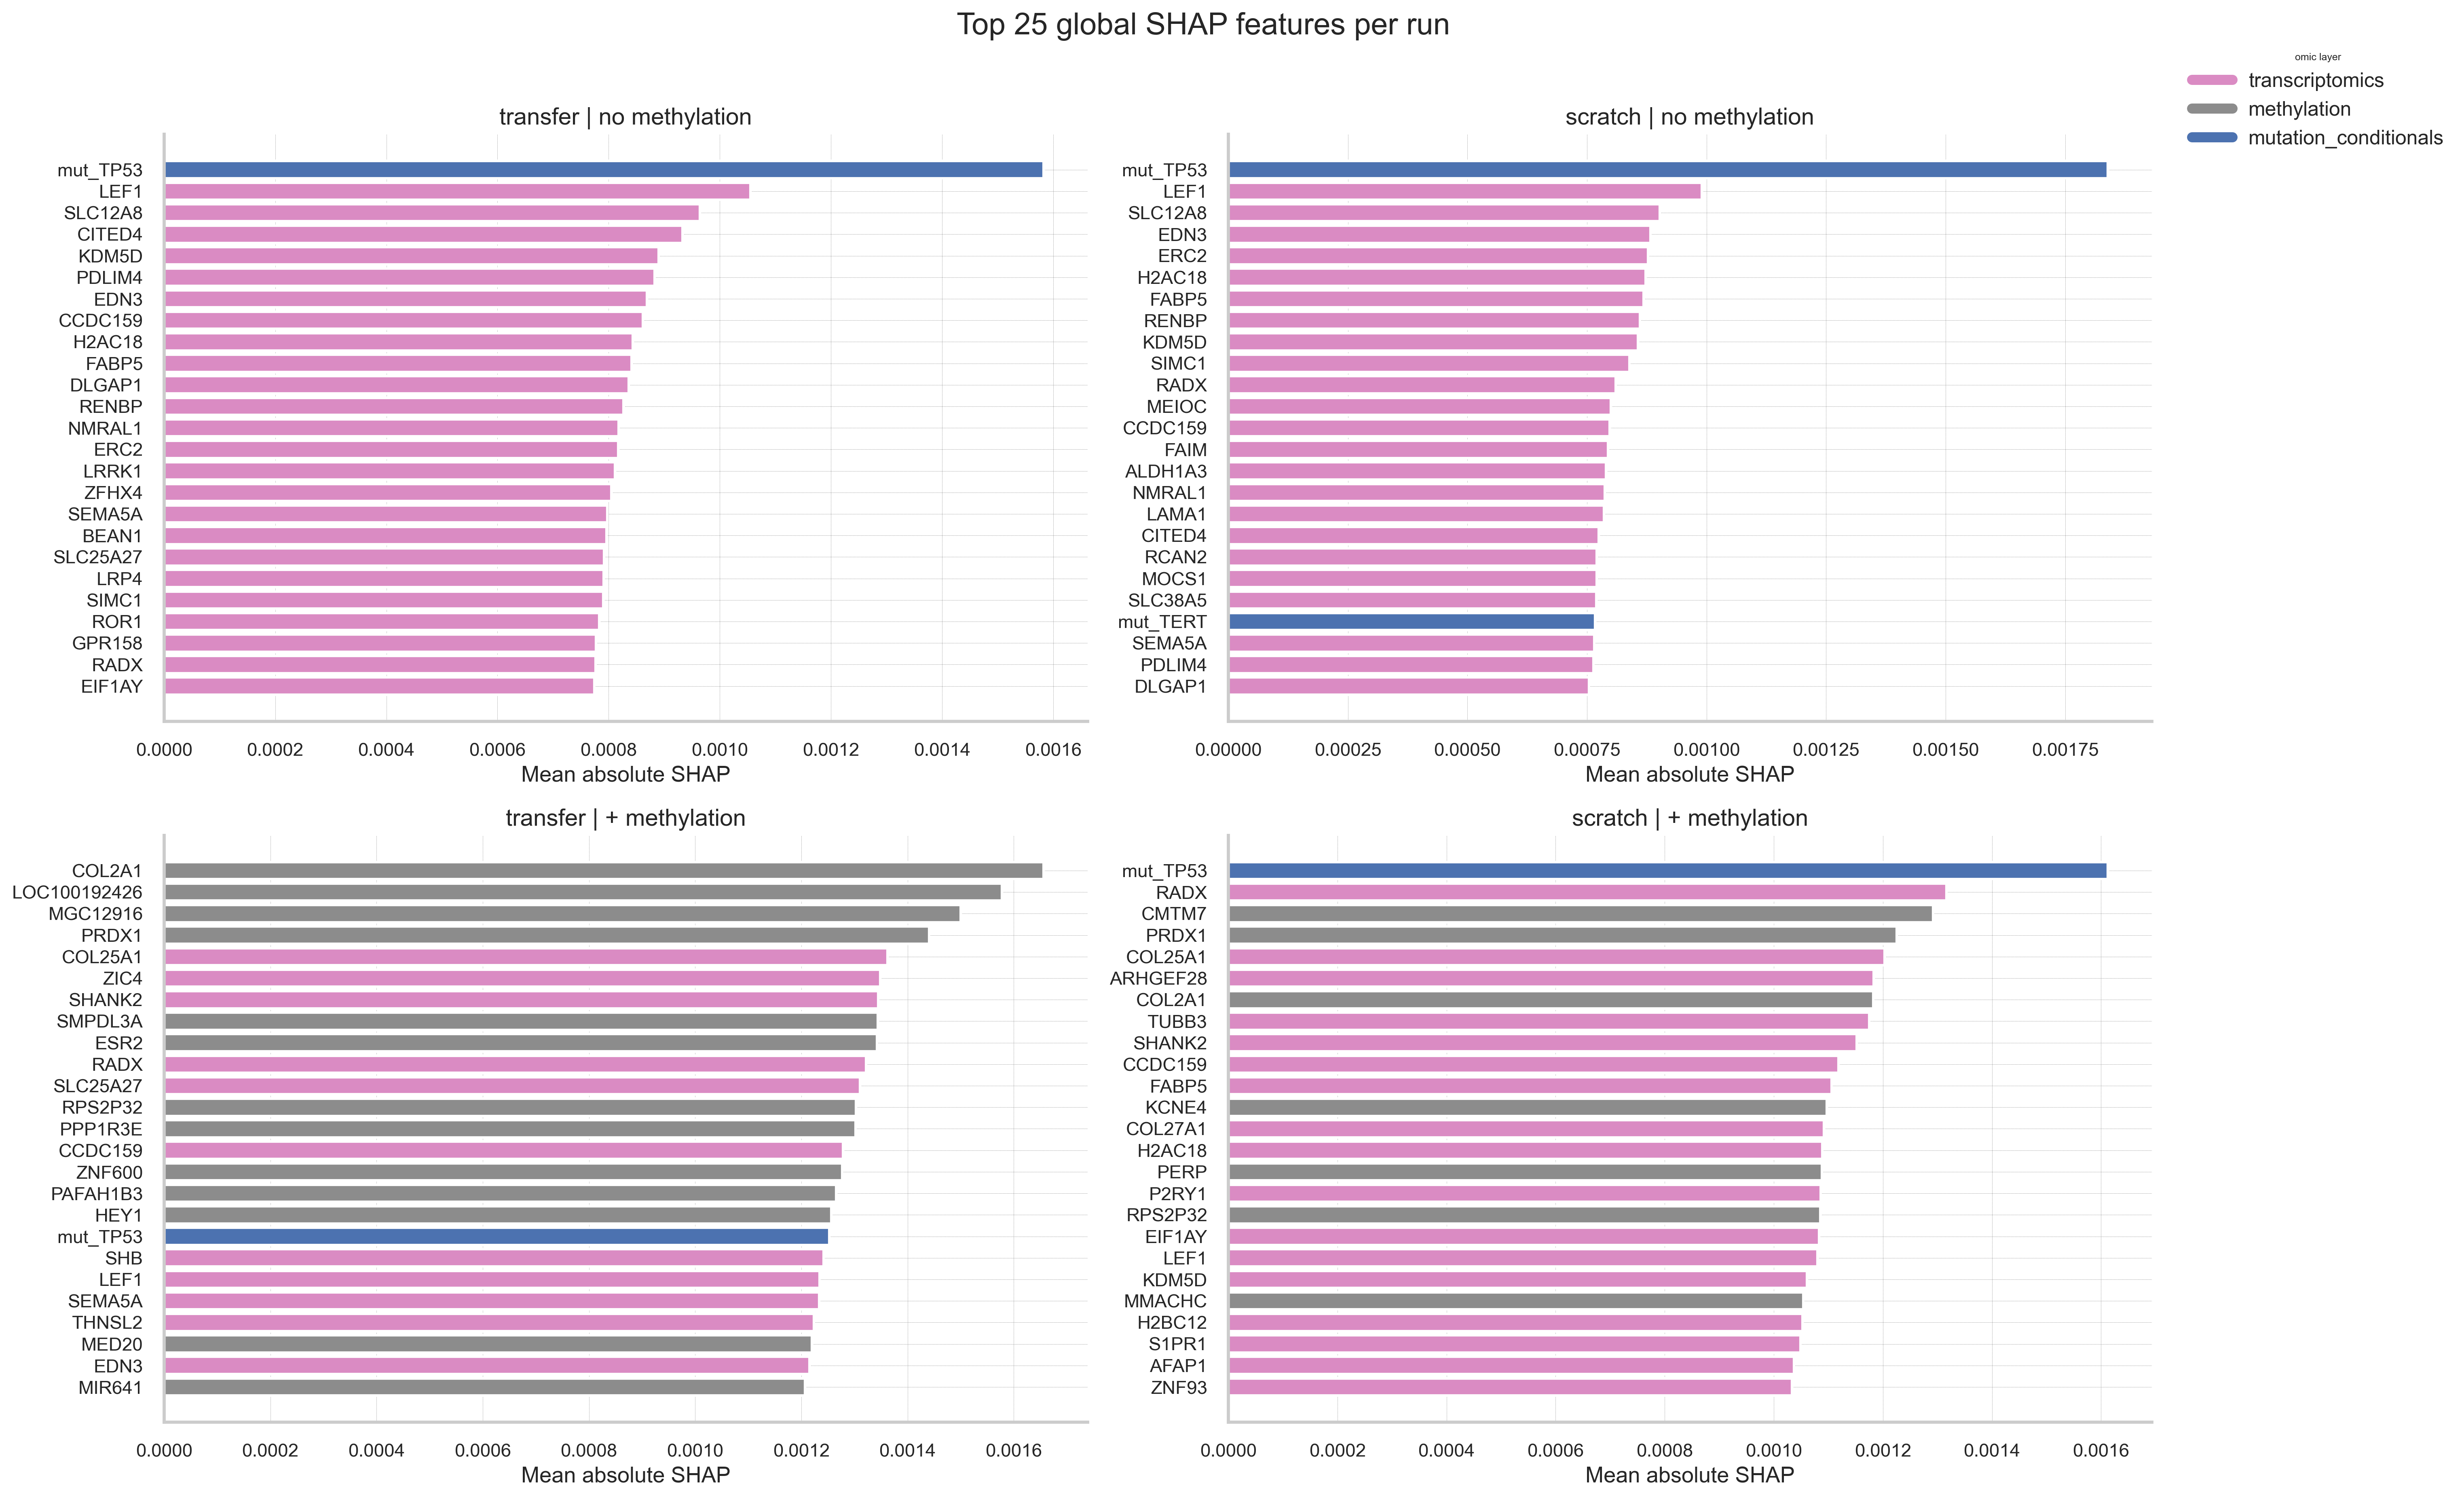

,timestamp,display_label,feature,omic_layer,importance
0,20260225_133435,transfer | no methylation,conditionals_mut_TP53,mutation_conditionals,0.001583
1,20260225_133435,transfer | no methylation,transcriptomics_LEF1,transcriptomics,0.001055
2,20260225_133435,transfer | no methylation,transcriptomics_SLC12A8,transcriptomics,0.000964
3,20260225_133435,transfer | no methylation,transcriptomics_CITED4,transcriptomics,0.000933
4,20260225_133435,transfer | no methylation,transcriptomics_KDM5D,transcriptomics,0.000890
...,...,...,...,...,...
95,20260226_031500,scratch | + methylation,methylation_MMACHC,methylation,0.001054
96,20260226_031500,scratch | + methylation,transcriptomics_H2BC12,transcriptomics,0.001053
97,20260226_031500,scratch | + methylation,transcriptomics_S1PR1,transcriptomics,0.001049
98,20260226_031500,scratch | + methylation,transcriptomics_AFAP1,transcriptomics,0.001037


In [28]:
GLOBAL_TOP_N = 25

run_order = runs_df["display_label"].tolist()
ts_to_label = dict(zip(runs_df["timestamp"], runs_df["display_label"]))
label_to_ts = dict(zip(runs_df["display_label"], runs_df["timestamp"]))

n_runs = len(run_order)
ncols = 2
nrows = int(np.ceil(n_runs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 6.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, run_label in zip(axes_flat, run_order):
    ts = label_to_ts[run_label]
    top_df = (
        shap_feature_df[shap_feature_df["timestamp"] == ts]
        .sort_values("importance", ascending=False)
        .head(GLOBAL_TOP_N)
        .copy()
    )
    top_df["feature_short"] = top_df["feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    top_df = top_df.iloc[::-1]

    bar_colors = [palette.get(v, "#8c8c8c") for v in top_df["omic_layer"]]
    ax.barh(top_df["feature_short"], top_df["importance"], color=bar_colors)
    ax.set_title(run_label, fontsize=14)
    ax.set_xlabel("Mean absolute SHAP", fontsize=13)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)

for ax in axes_flat[n_runs:]:
    ax.axis("off")

legend_layers = [
    l for l in ["transcriptomics", "methylation", "mutation_conditionals"]
    if l in set(shap_feature_df["omic_layer"])
]
legend_handles = [
    plt.Line2D([0], [0], color=palette.get(l, "#8c8c8c"), lw=6) for l in legend_layers
]
if legend_handles:
    fig.legend(
        legend_handles,
        legend_layers,
        title="omic layer",
        bbox_to_anchor=(0.9, 0.98),
        loc="upper left",
        fontsize=12,
    )

fig.suptitle(f"Top {GLOBAL_TOP_N} global SHAP features per run", y=0.995, fontsize=18)
fig.tight_layout(rect=[0, 0, 0.9, 0.98])
fig.savefig(OUT_DIR / "shap_global_top_features_per_run.png", dpi=220)
plt.show()

global_top_table = (
    shap_feature_df.sort_values(["timestamp", "importance"], ascending=[True, False])
    .groupby("timestamp", as_index=False)
    .head(GLOBAL_TOP_N)
    [["timestamp", "display_label", "feature", "omic_layer", "importance"]]
    .reset_index(drop=True)
)
display(global_top_table)


### Target List Analysis

Plots top features for selected CRISPR target genes for each run.


In [29]:
TARGET_GENE_LIST = ["MDM2", "MDM4", "PIK3CA"]
TARGET_TOP_N = 20
CHUNK_SIZE = 48
PREFER_FEATHER = True


def _summarize_target_from_long_df(long_df, target_genes):
    if long_df is None or long_df.empty:
        return pd.DataFrame(
            columns=["target_name", "feature", "omic_layer", "feature_short", "abs_shap"]
        )

    tmp = long_df.copy()
    tmp = tmp[tmp["target_name"].isin(target_genes)].copy()
    if tmp.empty:
        return pd.DataFrame(
            columns=["target_name", "feature", "omic_layer", "feature_short", "abs_shap"]
        )

    if "Shap_value" not in tmp.columns:
        raise ValueError("Expected column 'Shap_value' in target-level long SHAP data.")

    tmp["abs_shap"] = tmp["Shap_value"].abs()
    feature_col = "omics_feature" if "omics_feature" in tmp.columns else "feature"
    tmp = tmp.rename(columns={feature_col: "feature"})

    out = (
        tmp.groupby(["target_name", "feature"], as_index=False)["abs_shap"]
        .mean()
        .sort_values(["target_name", "abs_shap"], ascending=[True, False])
    )
    out["omic_layer"] = out["feature"].str.split("_").str[0].replace(
        {"conditionals": "mutation_conditionals"}
    )
    out["feature_short"] = out["feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    return out


def _summarize_target_from_full_csv(full_shap_csv, target_genes, chunk_size=64):
    if not full_shap_csv.exists():
        return pd.DataFrame(
            columns=["target_name", "feature", "omic_layer", "feature_short", "abs_shap"]
        )

    header_cols = pd.read_csv(full_shap_csv, nrows=0).columns.tolist()
    feature_cols = [c for c in header_cols if c not in {"target_name", "Sample ID"}]
    if not feature_cols:
        return pd.DataFrame(
            columns=["target_name", "feature", "omic_layer", "feature_short", "abs_shap"]
        )

    target_genes = list(dict.fromkeys(target_genes))
    abs_sums = {g: pd.Series(0.0, index=feature_cols, dtype=float) for g in target_genes}
    counts = {g: 0 for g in target_genes}

    for chunk in pd.read_csv(full_shap_csv, chunksize=chunk_size):
        chunk = chunk[chunk["target_name"].isin(target_genes)]
        if chunk.empty:
            continue

        for g, gdf in chunk.groupby("target_name"):
            abs_sums[g] = abs_sums[g].add(gdf[feature_cols].abs().sum(axis=0), fill_value=0.0)
            counts[g] += len(gdf)

    parts = []
    for g in target_genes:
        if counts[g] == 0:
            continue
        mean_abs = (abs_sums[g] / counts[g]).rename("abs_shap")
        tmp = mean_abs.reset_index().rename(columns={"index": "feature"})
        tmp["target_name"] = g
        parts.append(tmp)

    if not parts:
        return pd.DataFrame(
            columns=["target_name", "feature", "omic_layer", "feature_short", "abs_shap"]
        )

    out = pd.concat(parts, ignore_index=True)
    out["omic_layer"] = out["feature"].str.split("_").str[0].replace(
        {"conditionals": "mutation_conditionals"}
    )
    out["feature_short"] = out["feature"].map(
        lambda x: x.split("_", 1)[1] if "_" in x else x
    )
    return out.sort_values(["target_name", "abs_shap"], ascending=[True, False])


def load_target_feature_summary_for_run(ts, target_genes, chunk_size=64, prefer_feather=True):
    feather_path = FILES_DIR / f"{ts}_shap_values_top_features_crisprcas9.feather"
    full_csv_path = FILES_DIR / f"{ts}_shap_values_crisprcas9.csv.gz"

    if prefer_feather and feather_path.exists():
        try:
            long_df = pd.read_feather(feather_path)
            out = _summarize_target_from_long_df(long_df, target_genes)
            if not out.empty:
                out["source_used"] = "top_features_feather"
                return out
        except Exception as exc:
            print(f"[{ts}] Feather read failed ({type(exc).__name__}); falling back to full CSV.")

    out = _summarize_target_from_full_csv(full_csv_path, target_genes, chunk_size=chunk_size)
    if not out.empty:
        out["source_used"] = "full_shap_csv"
    return out


target_summary_parts = []
for ts in runs_df["timestamp"]:
    run_summary = load_target_feature_summary_for_run(
        ts,
        TARGET_GENE_LIST,
        chunk_size=CHUNK_SIZE,
        prefer_feather=PREFER_FEATHER,
    )
    if run_summary.empty:
        print(f"[{ts}] No target-level SHAP records found for {TARGET_GENE_LIST}.")
        continue
    run_summary["timestamp"] = ts
    target_summary_parts.append(run_summary)

target_summary_df = (
    pd.concat(target_summary_parts, ignore_index=True)
    if target_summary_parts
    else pd.DataFrame(
        columns=[
            "target_name", "feature", "omic_layer", "feature_short", "abs_shap",
            "source_used", "timestamp"
        ]
    )
)
target_summary_df = target_summary_df.merge(
    runs_df[["timestamp", "display_label", "mode", "methylation"]],
    on="timestamp",
    how="left",
)

if target_summary_df.empty:
    print("No target-level summary was loaded.")
else:
    display(target_summary_df.head())
    display(
        target_summary_df.groupby(["timestamp", "target_name", "source_used"], as_index=False)
        .size()
        .rename(columns={"size": "n_features"})
    )


[20260225_133435] No target-level SHAP records found for ['MDM2', 'MDM4', 'PIK3CA'].
[20260226_024535] No target-level SHAP records found for ['MDM2', 'MDM4', 'PIK3CA'].
[20260226_031500] No target-level SHAP records found for ['MDM2', 'MDM4', 'PIK3CA'].


,target_name,feature,abs_shap,omic_layer,feature_short,source_used,timestamp,display_label,mode,methylation
0,MDM2,conditionals_mut_TP53,0.014200,mutation_conditionals,mut_TP53,top_features_feather,20260225_223235,scratch | no methylation,scratch,False
1,MDM2,conditionals_mut_TERT,0.001555,mutation_conditionals,mut_TERT,top_features_feather,20260225_223235,scratch | no methylation,scratch,False
2,MDM2,conditionals_mut_H3_3A_p_K28M,0.001333,mutation_conditionals,mut_H3_3A_p_K28M,top_features_feather,20260225_223235,scratch | no methylation,scratch,False
3,MDM2,transcriptomics_EDA2R,0.001179,transcriptomics,EDA2R,top_features_feather,20260225_223235,scratch | no methylation,scratch,False
4,MDM2,transcriptomics_BBC3,0.001031,transcriptomics,BBC3,top_features_feather,20260225_223235,scratch | no methylation,scratch,False


,timestamp,target_name,source_used,n_features
0,20260225_223235,MDM2,top_features_feather,400
1,20260225_223235,MDM4,top_features_feather,400
2,20260225_223235,PIK3CA,top_features_feather,400


No target-level rows for transfer | no methylation


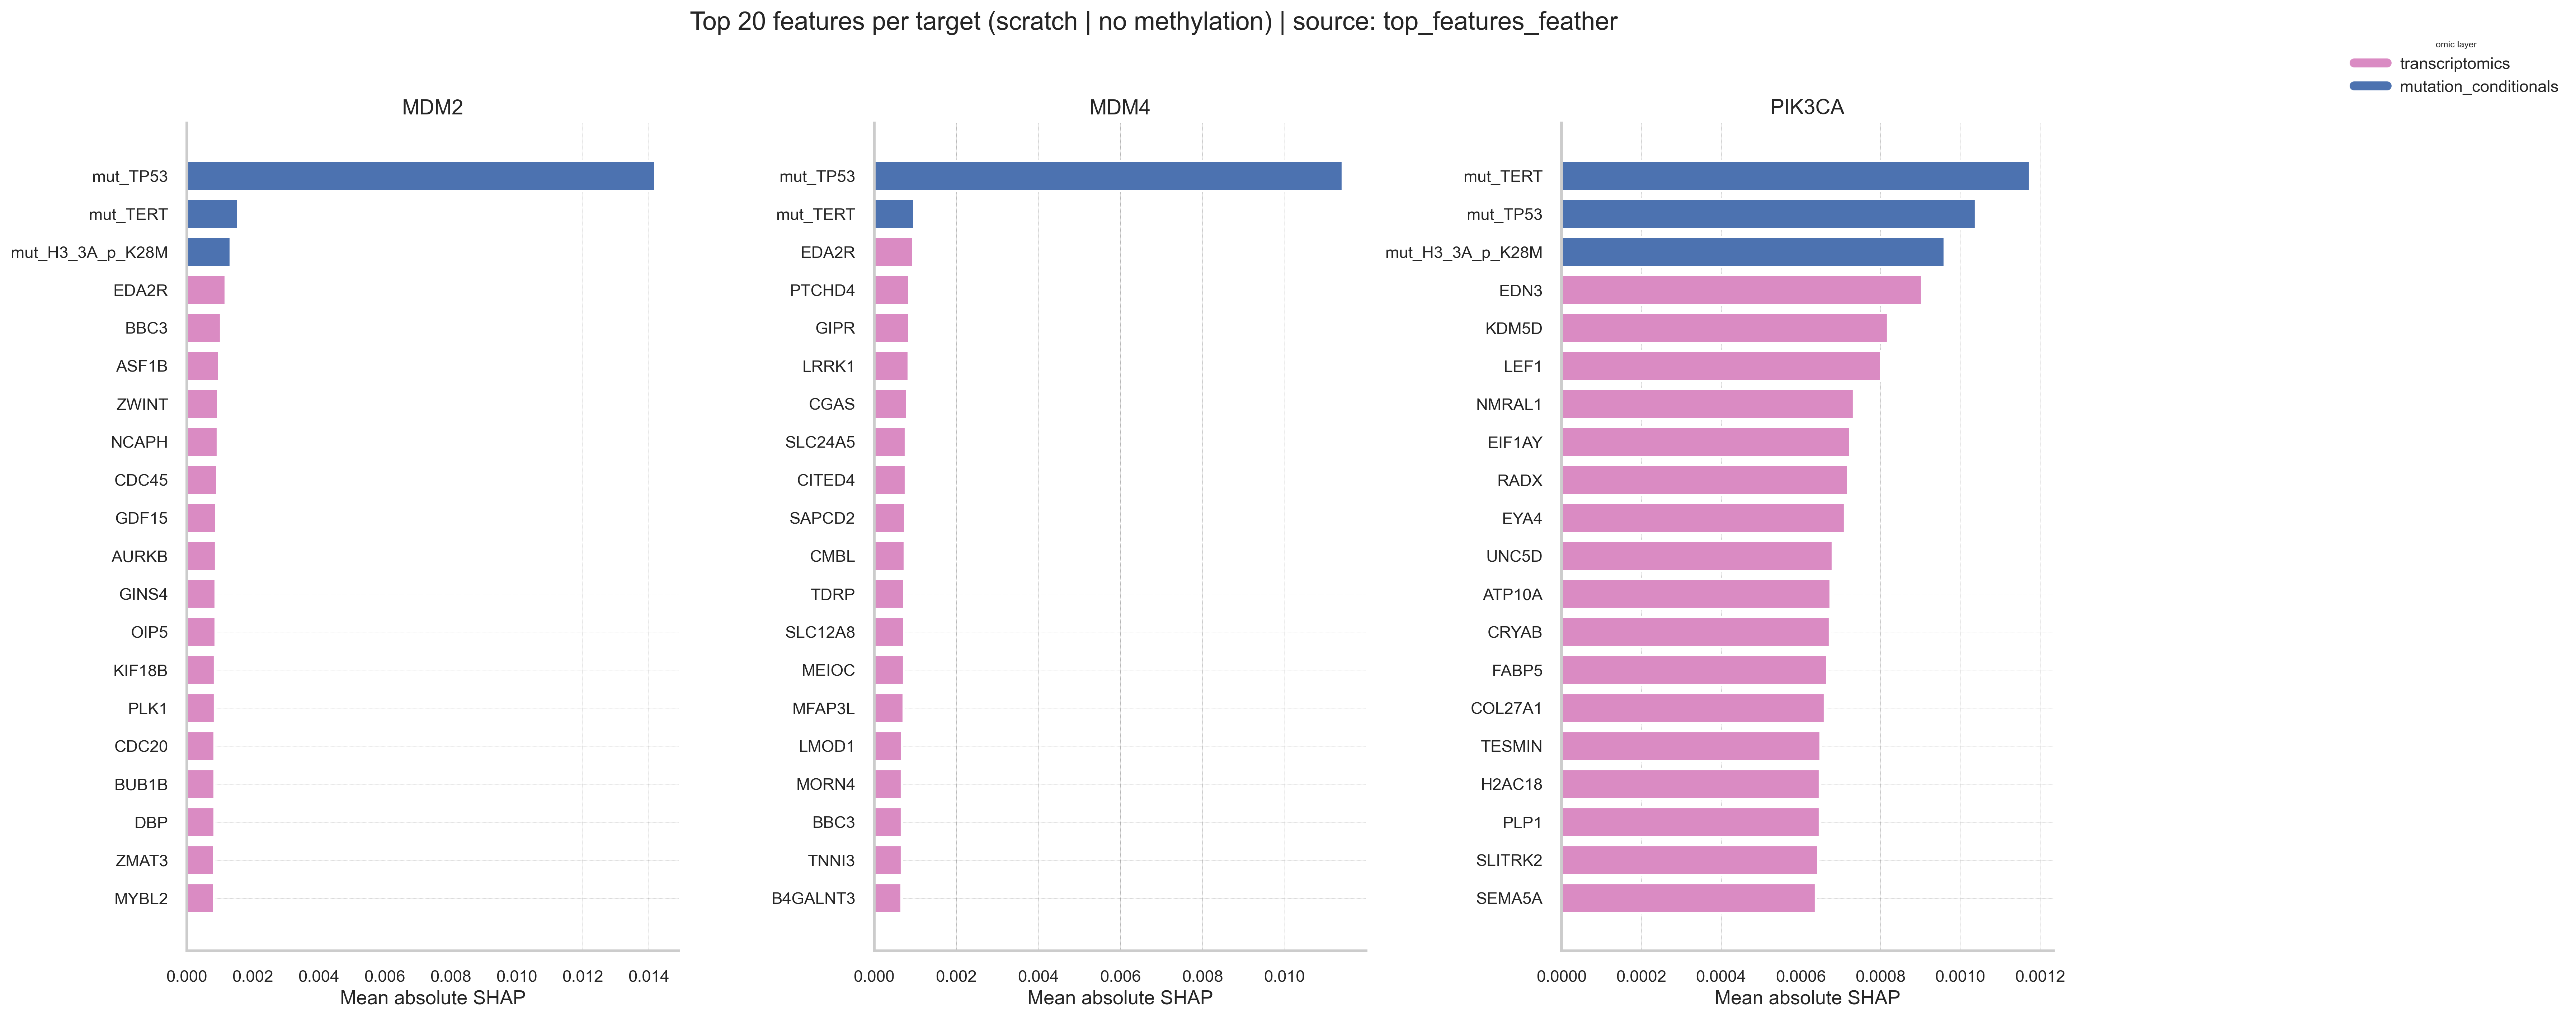

No target-level rows for transfer | + methylation
No target-level rows for scratch | + methylation


,display_label,target_name,feature,omic_layer,abs_shap
0,scratch | no methylation,MDM2,conditionals_mut_TP53,mutation_conditionals,0.014200
1,scratch | no methylation,MDM2,conditionals_mut_TERT,mutation_conditionals,0.001555
2,scratch | no methylation,MDM2,conditionals_mut_H3_3A_p_K28M,mutation_conditionals,0.001333
3,scratch | no methylation,MDM2,transcriptomics_EDA2R,transcriptomics,0.001179
4,scratch | no methylation,MDM2,transcriptomics_BBC3,transcriptomics,0.001031
5,scratch | no methylation,MDM2,transcriptomics_ASF1B,transcriptomics,0.000979
6,scratch | no methylation,MDM2,transcriptomics_ZWINT,transcriptomics,0.000945
7,scratch | no methylation,MDM2,transcriptomics_NCAPH,transcriptomics,0.000939
8,scratch | no methylation,MDM2,transcriptomics_CDC45,transcriptomics,0.000921
9,scratch | no methylation,MDM2,transcriptomics_GDF15,transcriptomics,0.000891


In [30]:
if target_summary_df.empty:
    print("No target-level data available for plotting.")
else:
    run_order = runs_df["display_label"].tolist()
    for run_label in run_order:
        run_df = target_summary_df[target_summary_df["display_label"] == run_label].copy()
        if run_df.empty:
            print(f"No target-level rows for {run_label}")
            continue

        n_targets = len(TARGET_GENE_LIST)
        fig, axes = plt.subplots(1, n_targets, figsize=(7.2 * n_targets, 9.5), squeeze=False)
        axes = axes.flatten()

        for ax, gene in zip(axes, TARGET_GENE_LIST):
            gdf = (
                run_df[run_df["target_name"] == gene]
                .sort_values("abs_shap", ascending=False)
                .head(TARGET_TOP_N)
                .copy()
            )

            if gdf.empty:
                ax.text(0.5, 0.5, "No SHAP rows", ha="center", va="center", transform=ax.transAxes, fontsize=13)
                ax.set_axis_off()
                ax.set_title(gene, fontsize=14)
                continue

            gdf = gdf.iloc[::-1]
            colors = [palette.get(v, "#8c8c8c") for v in gdf["omic_layer"]]
            ax.barh(gdf["feature_short"], gdf["abs_shap"], color=colors)
            ax.set_title(gene, fontsize=14)
            ax.set_xlabel("Mean absolute SHAP", fontsize=13)
            ax.set_ylabel("")
            ax.tick_params(axis="x", labelsize=11)
            ax.tick_params(axis="y", labelsize=11)

        source_used = ", ".join(sorted(run_df["source_used"].dropna().unique()))
        fig.suptitle(
            f"Top {TARGET_TOP_N} features per target ({run_label}) | source: {source_used}",
            y=0.995,
            fontsize=17,
        )

        legend_layers = [
            l for l in ["transcriptomics", "methylation", "mutation_conditionals"]
            if l in set(run_df["omic_layer"])
        ]
        legend_handles = [
            plt.Line2D([0], [0], color=palette.get(l, "#8c8c8c"), lw=6) for l in legend_layers
        ]
        if legend_handles:
            fig.legend(
                legend_handles,
                legend_layers,
                title="omic layer",
                bbox_to_anchor=(1.01, 0.98),
                loc="upper left",
                fontsize=11,
            )

        fig.tight_layout(rect=[0, 0, 0.9, 0.97])
        ts = run_df["timestamp"].iloc[0]
        fig.savefig(OUT_DIR / f"{ts}_target_list_top_features.png", dpi=220)
        plt.show()

    plot_table = (
        target_summary_df.sort_values(["display_label", "target_name", "abs_shap"], ascending=[True, True, False])
        .groupby(["display_label", "target_name"], as_index=False)
        .head(TARGET_TOP_N)
        [["display_label", "target_name", "feature", "omic_layer", "abs_shap"]]
        .reset_index(drop=True)
    )
    display(plot_table)
